# 販売予測AIエージェント デモ（試作）

イベント・観光分野を想定した **翌日の売上金額予測** のデモです。

このノートブックでは、AI（機械学習）が **実際に過去データを学習し、予測を出す** 一連の流れを体感します。

## 流れ
1. **合成データ生成** … 現実的なパターン（曜日・季節・祝日・天候・SNS）を埋め込んだ疑似データ
2. **特徴量エンジニアリング** … 予測時点で入手可能な情報だけを使う（データリーク対策）
3. **時系列分割** … 過去で学習 → 未来で検証
4. **モデル学習** … 勾配ブースティング（HistGradientBoostingRegressor）
5. **翌日予測**
6. **精度評価** … MAE / RMSE / MAPE ＋ ピーク日誤差。単純ベースラインと比較

> 実データが無い段階なので合成データを使いますが、コードはそのまま実データに差し替えられる構成です。

In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl")

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

# src/ を import パスに追加
sys.path.append(str(Path.cwd() / "src"))
from synthetic_data import generate_synthetic_data

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)

# 日本語フォント（無い環境でも文字化けで止まらないようにフォールバック）
for _f in ["Hiragino Sans", "Yu Gothic", "Meiryo", "IPAexGothic", "Noto Sans CJK JP"]:
    if any(_f in f.name for f in matplotlib.font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False

print("セットアップ完了 / pandas", pd.__version__)

セットアップ完了 / pandas 3.0.3


## 1. 合成データの生成

2年分（730日）の日次データを生成します。以下の現実的な傾向を **意図的に** 埋め込んでいます。

- 週末・金曜は売上が高い（曜日周期）
- 春・秋の行楽シーズンに需要が高い（季節性）
- 祝日・連休は上振れ
- 雨の日は減少、快適な気温で増加（天候影響）
- **翌日の需要を先取りしてSNS言及数が増える**（＝前日のSNSが翌日売上の先行指標）

モデルがこれらの傾向を学習できれば「学習成功」と判断できます。

In [2]:
df_raw = generate_synthetic_data(start="2024-01-01", days=730, seed=42)
print("データ件数:", len(df_raw), "／期間:", df_raw["date"].min().date(), "〜", df_raw["date"].max().date())
df_raw.head(10)

データ件数: 730 ／期間: 2024-01-01 〜 2025-12-30


,date,sales_amount,temp_max,temp_min,precipitation_mm,weather,sns_mentions
0,2024-01-01,289473,11.0,1.2,0.0,cloudy,183
1,2024-01-02,221508,8.9,0.5,0.0,sunny,181
2,2024-01-03,248098,11.5,1.2,0.0,sunny,139
3,2024-01-04,243408,11.8,0.1,0.0,cloudy,268
4,2024-01-05,284229,7.4,0.7,0.0,cloudy,342
5,2024-01-06,430361,8.3,0.5,0.0,cloudy,289
6,2024-01-07,321153,10.4,1.4,0.0,sunny,254
7,2024-01-08,275988,9.7,1.4,0.0,sunny,205
8,2024-01-09,199832,10.1,-2.3,0.0,cloudy,146
9,2024-01-10,244446,8.8,-3.2,0.0,sunny,180


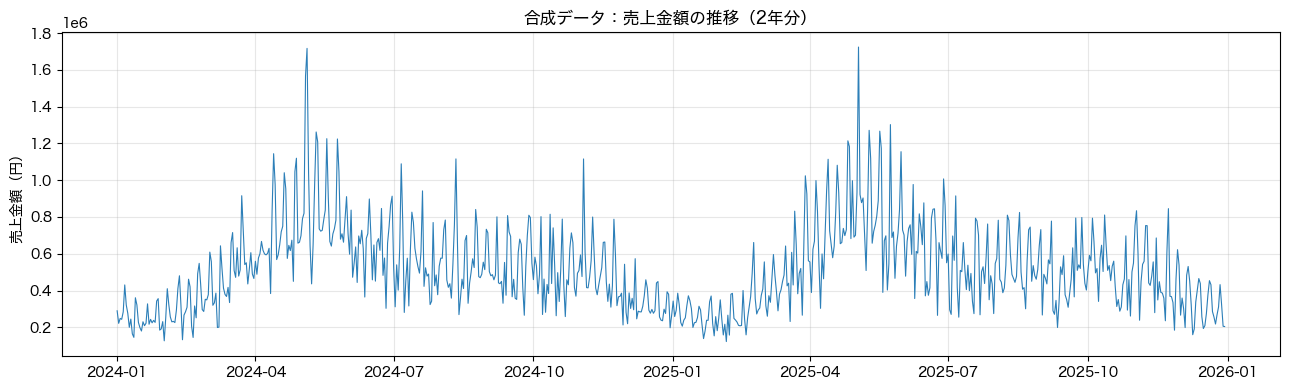

In [3]:
# 売上の推移をざっと可視化
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df_raw["date"], df_raw["sales_amount"], lw=0.8, color="#2c7fb8")
ax.set_title("合成データ：売上金額の推移（2年分）")
ax.set_ylabel("売上金額（円）")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. 特徴量エンジニアリング（データリーク対策が肝）

「翌日（target日）の売上」を予測するとき、**予測時点（前日の夜）で実際に手に入る情報だけ**を使わなければなりません。これを破ると、検証では高精度なのに本番でまったく使えないモデルになります（データリーク）。

本デモでの整理:

| 種類 | 使い方 | 理由 |
|---|---|---|
| カレンダー（target日の曜日・祝日・連休） | そのまま使用 | カレンダーは未来でも確定している |
| 天候（target日の気温・降水） | **予報値** として使用 | 翌日の天気予報は前日に入手可能 |
| SNS言及数 | **前日まで** の値・移動平均を使用 | target日当日の値は予測時点で未取得 |
| 売上 | **前日・7日前・前年同日** のラグを使用 | 過去の実績は入手可能 |

下のセルでは、各行が「その日付（target日）を予測するための特徴量」になるよう構築します。

In [4]:
import jpholiday

def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """各行 = その日付(target日)を予測するための特徴量テーブルを作る."""
    d = df.copy().sort_values("date").reset_index(drop=True)
    dt = d["date"].dt

    # --- カレンダー系（target日。未来でも確定）---
    d["dow"] = dt.dayofweek
    d["month"] = dt.month
    d["weekofyear"] = dt.isocalendar().week.astype(int)
    d["is_weekend"] = (d["dow"] >= 5).astype(int)
    d["is_holiday"] = d["date"].apply(lambda x: int(jpholiday.is_holiday(x.date())))
    # 連休フラグ（祝日 or 週末が連続する日）
    off = ((d["is_weekend"] == 1) | (d["is_holiday"] == 1)).astype(int)
    d["is_longweekend"] = ((off == 1) & (off.shift(1, fill_value=0) == 1)).astype(int)
    # 祝日の前日・翌日
    d["holiday_eve"] = d["is_holiday"].shift(-1, fill_value=0)
    d["holiday_next"] = d["is_holiday"].shift(1, fill_value=0)

    # --- 天候系（target日の "予報値" という想定。当日分を使ってOK）---
    d["rain_flag"] = (d["precipitation_mm"] >= 1.0).astype(int)
    d["heavy_rain_flag"] = (d["precipitation_mm"] >= 20.0).astype(int)
    d["comfortable_temp"] = (((d["temp_max"] >= 18) & (d["temp_max"] <= 26))).astype(int)
    d["temp_range"] = d["temp_max"] - d["temp_min"]

    # --- SNS系（前日まで。当日値は使わない＝1日シフト）---
    d["sns_lag1"] = d["sns_mentions"].shift(1)
    d["sns_ma3"] = d["sns_mentions"].shift(1).rolling(3).mean()
    d["sns_ma7"] = d["sns_mentions"].shift(1).rolling(7).mean()
    d["sns_surge"] = (d["sns_lag1"] > d["sns_ma7"] * 1.2).astype(int)

    # --- 売上ラグ系（過去実績。入手可能）---
    d["sales_lag1"] = d["sales_amount"].shift(1)
    d["sales_lag7"] = d["sales_amount"].shift(7)
    d["sales_lag365"] = d["sales_amount"].shift(365)
    d["sales_ma7"] = d["sales_amount"].shift(1).rolling(7).mean()
    d["sales_ma30"] = d["sales_amount"].shift(1).rolling(30).mean()

    return d

FEATURES = [
    # カレンダー
    "dow", "month", "weekofyear", "is_weekend", "is_holiday",
    "is_longweekend", "holiday_eve", "holiday_next",
    # 天候（予報値）
    "temp_max", "temp_min", "precipitation_mm", "rain_flag",
    "heavy_rain_flag", "comfortable_temp", "temp_range",
    # SNS（前日まで）
    "sns_lag1", "sns_ma3", "sns_ma7", "sns_surge",
    # 売上ラグ
    "sales_lag1", "sales_lag7", "sales_ma7", "sales_ma30",
]
TARGET = "sales_amount"

df_feat = build_features(df_raw)
# ラグ生成で先頭に NaN が出るため、特徴が揃う行だけ残す
df_feat = df_feat.dropna(subset=[c for c in FEATURES if c != "sales_lag365"]).reset_index(drop=True)
print("特徴量テーブル:", df_feat.shape, "／特徴量数:", len(FEATURES))
df_feat[["date", TARGET] + FEATURES].head()

特徴量テーブル: (700, 28) ／特徴量数: 23


,date,sales_amount,dow,month,weekofyear,is_weekend,is_holiday,is_longweekend,holiday_eve,holiday_next,temp_max,temp_min,precipitation_mm,rain_flag,heavy_rain_flag,comfortable_temp,temp_range,sns_lag1,sns_ma3,sns_ma7,sns_surge,sales_lag1,sales_lag7,sales_ma7,sales_ma30
0,2024-01-31,230747,2,1,5,0,0,0,0,0,13.5,2.1,0.0,0,0,0,11.4,227.0,213.333333,226.714286,0,191060.0,224260.0,251738.142857,252103.166667
1,2024-02-01,126320,3,2,5,0,0,0,0,0,9.7,1.2,19.1,1,0,0,8.5,168.0,194.333333,224.571429,0,230747.0,237335.0,252664.857143,250145.633333
2,2024-02-02,254329,4,2,5,0,0,0,0,0,9.6,1.4,0.0,0,0,0,8.2,198.0,197.666667,222.571429,0,126320.0,226553.0,236805.571429,246972.700000
3,2024-02-03,409863,5,2,5,1,0,0,0,0,9.2,1.3,0.0,0,0,0,7.9,264.0,210.000000,212.428571,1,254329.0,342611.0,240773.571429,247180.400000
4,2024-02-04,323078,6,2,5,1,0,1,0,0,11.4,0.9,5.2,1,0,0,10.5,311.0,257.666667,225.857143,1,409863.0,355748.0,250381.000000,252728.900000


## 3. 時系列分割（過去で学習 → 未来で検証）

時系列予測では、ランダム分割は厳禁です（未来の情報で過去を予測してしまう）。
ここでは **直近90日を検証期間**、それより前を学習期間とします。

In [5]:
TEST_DAYS = 90
split_idx = len(df_feat) - TEST_DAYS

train = df_feat.iloc[:split_idx]
test = df_feat.iloc[split_idx:]

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

print(f"学習期間: {train['date'].min().date()} 〜 {train['date'].max().date()}  ({len(train)}日)")
print(f"検証期間: {test['date'].min().date()} 〜 {test['date'].max().date()}  ({len(test)}日)")

学習期間: 2024-01-31 〜 2025-10-01  (610日)
検証期間: 2025-10-02 〜 2025-12-30  (90日)


## 4. モデル学習（勾配ブースティング）

`HistGradientBoostingRegressor` で学習します。これは LightGBM と同じ「ヒストグラム型勾配ブースティング」系のアルゴリズムで、欠損値（前年同日ラグの NaN など）もそのまま扱えます。

In [6]:
model = HistGradientBoostingRegressor(
    max_iter=500,
    learning_rate=0.05,
    max_depth=6,
    l2_regularization=1.0,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=42,
)
model.fit(X_train, y_train)
print("学習完了。実行した木の数:", model.n_iter_)

学習完了。実行した木の数: 295


## 5. 翌日予測 ＆ 6. 精度評価

検証期間（直近90日）について、各日の翌日売上を予測し、実績と比較します。
比較対象として、機械学習を使わない単純な **ベースライン** も用意します。

- **ベースラインA**: 前年同日の売上（無ければ7日前）
- **ベースラインB**: 直近7日の移動平均

評価指標は MAE / RMSE / MAPE に加え、**ピーク日（売上上位20%）に絞った MAPE** も見ます（スパイク型需要の当て具合）。

In [7]:
# --- モデル予測 ---
pred_model = model.predict(X_test)

# --- ベースライン ---
# A: 前年同日（無ければ7日前ラグ）
base_a = test["sales_lag365"].fillna(test["sales_lag7"]).values
# B: 直近7日移動平均
base_b = test["sales_ma7"].values

def evaluate(name, y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    # ピーク日（上位20%）に絞った MAPE
    thr = np.quantile(y_true, 0.8)
    peak = y_true >= thr
    peak_mape = np.mean(np.abs((y_true[peak] - y_pred[peak]) / y_true[peak])) * 100
    return {"モデル": name, "MAE": mae, "RMSE": rmse, "MAPE(%)": mape, "ピーク日MAPE(%)": peak_mape}

results = pd.DataFrame([
    evaluate("勾配ブースティング(本命)", y_test, pred_model),
    evaluate("ベースラインA(前年同日)", y_test, base_a),
    evaluate("ベースラインB(7日移動平均)", y_test, base_b),
])
for c in ["MAE", "RMSE"]:
    results[c] = results[c].map(lambda v: f"{v:,.0f}")
for c in ["MAPE(%)", "ピーク日MAPE(%)"]:
    results[c] = results[c].map(lambda v: f"{v:.1f}")
results

,モデル,MAE,RMSE,MAPE(%),ピーク日MAPE(%)
0,勾配ブースティング(本命),"42,392","52,757",10.1,8.1
1,ベースラインA(前年同日),"129,823","172,628",32.8,28.5
2,ベースラインB(7日移動平均),"116,391","144,525",31.4,24.9


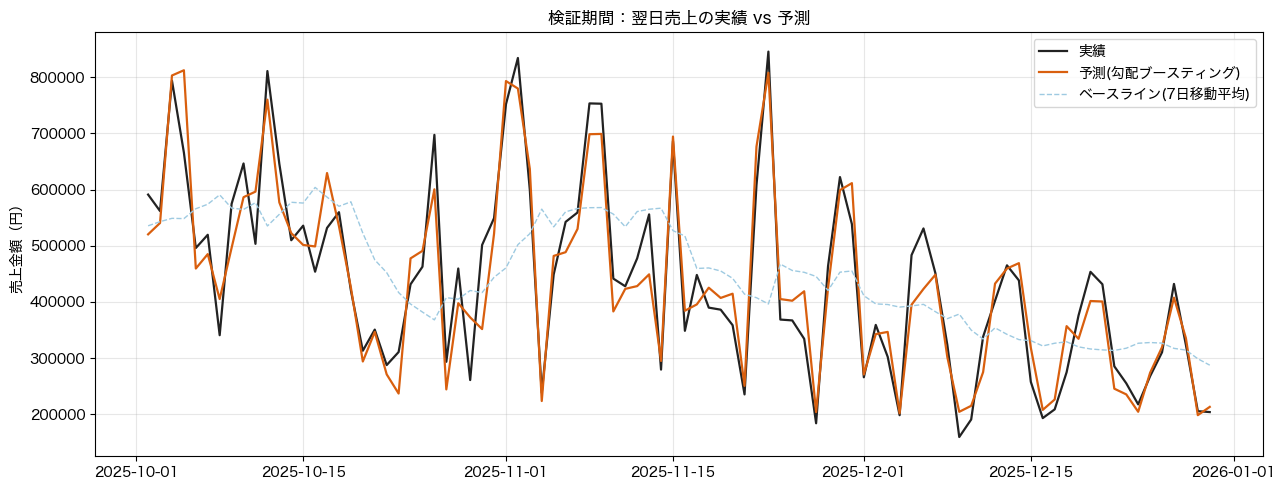

In [8]:
# --- 実績 vs 予測 の可視化 ---
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test["date"], y_test.values, label="実績", color="#222", lw=1.6)
ax.plot(test["date"], pred_model, label="予測(勾配ブースティング)", color="#d95f0e", lw=1.6)
ax.plot(test["date"], base_b, label="ベースライン(7日移動平均)", color="#9ecae1", lw=1.0, ls="--")
ax.set_title("検証期間：翌日売上の実績 vs 予測")
ax.set_ylabel("売上金額（円）")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. 何が効いたか（特徴量の重要度）

モデルが「どの情報を手がかりに予測したか」を、Permutation Importance（その特徴をシャッフルすると精度がどれだけ落ちるか）で確認します。
合成データに埋め込んだ傾向（曜日・SNS先行・天候など）が上位に来れば、狙い通り学習できている証拠です。

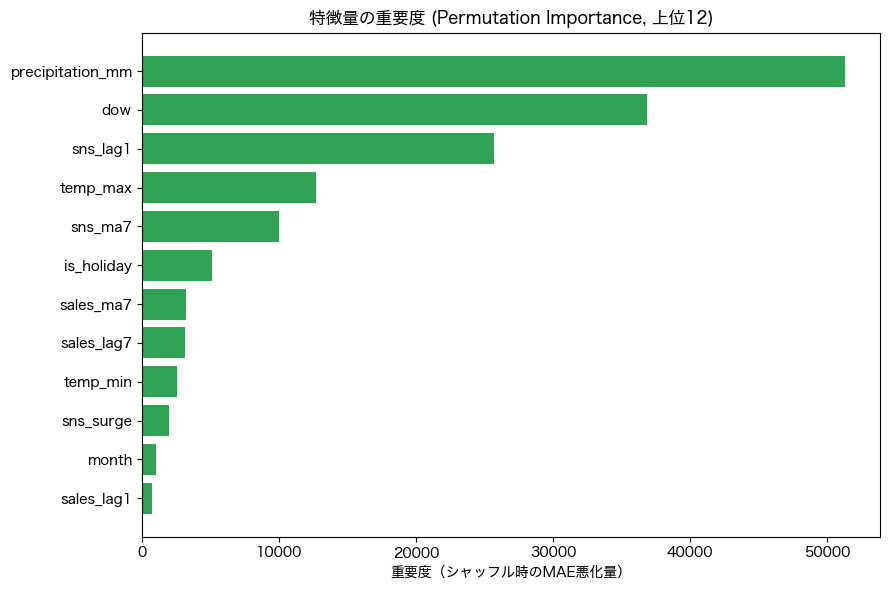

,feature,importance
0,precipitation_mm,51289.813028
1,dow,36870.389469
2,sns_lag1,25650.306788
3,temp_max,12687.505078
4,sns_ma7,9973.700974
5,is_holiday,5086.273787
6,sales_ma7,3226.972913
7,sales_lag7,3099.931358
8,temp_min,2561.025613
9,sns_surge,1998.735135


In [9]:
perm = permutation_importance(
    model, X_test, y_test, n_repeats=10, random_state=42,
    scoring="neg_mean_absolute_error",
)
imp = (
    pd.DataFrame({"feature": FEATURES, "importance": perm.importances_mean})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

top = imp.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top["feature"], top["importance"], color="#31a354")
ax.set_title("特徴量の重要度 (Permutation Importance, 上位12)")
ax.set_xlabel("重要度（シャッフル時のMAE悪化量）")
plt.tight_layout()
plt.show()

imp.head(12)

## まとめ

このデモで確認できること:

- **AIは「丸投げ」ではなく、設計に沿って実際に学習・予測する** … 合成データに埋め込んだ傾向を、勾配ブースティングが学習できた
- **単純ベースラインより精度が良い** … MAPE・ピーク日MAPE で機械学習の優位性を確認
- **データリーク対策が効いている** … 予測時点で入手可能な情報（カレンダー・予報天候・前日までのSNS・過去売上ラグ）だけで予測

### 本番フェーズへの差し替えポイント
1. `generate_synthetic_data()` を **実データ読み込み** に置き換える（CSV の売上実績、気象庁の天候、SNS取得結果）
2. 特徴量はそのまま流用可能（イベント開催情報・人流データを追加するとさらに精度向上が見込める）
3. 精度に納得できたら、LLMエージェントで「予測結果の解釈・施策提案・通知」を上に載せる

> ポイント：精度を決めるのは手法選びより **データの質・特徴量設計**。このデモはその検証土台になります。